In [ ]:
import numpy as np
from matplotlib import pyplot as plt
"""Aufbau: 
	S. 50 in der Dr-Arbeit	
"""


In [8]:
"""
Bestimmung der Müller-Matrix einer Probe
========================================

Aufbau:

    Grüner Laser
         |
         v
   Polarisator P
         |
         v
       Probe
         |
         v
   Analysator A
         |
         v
   Photodetektor

Das Skript simuliert Messungen und rekonstruiert anschließend
die 4x4-Müller-Matrix der Probe.

Annahmen:
- grüner Laser: lambda = 532 nm
- monochromatisches Licht
- ideale lineare Polarisatoren
- Intensitätsdetektor
- keine Depolarisation durch die optischen Komponenten
- Jones-/Mueller-Koordinatensystem:
      S = [I, Q, U, V]^T

Wichtig:
Für die vollständige Müller-Matrix sind mehrere unabhängige
Polarisationszustände notwendig. Ein einzelnes P-A-Paar bei
90° reicht nicht aus.
"""

import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. Grundeinstellungen
# ============================================================

WAVELENGTH = 532e-9       # 532 nm, grüner Laser
LASER_POWER = 1.0         # normierte Laserleistung


# ============================================================
# 2. Stokes-Vektor des Lasers
# ============================================================

def laser_stokes():
    """
    Linear polarisiertes Laserlicht.

    Der Laser wird hier als vollständig linear polarisiert
    in horizontaler Richtung angenommen.

    S = [I, Q, U, V]
    """
	#Stokes Vektor, (Intensität, vertikale Lineare Polarisation, 45° Lineare Polarisation, Zirkulare Polarisation)T
    return np.array([
        LASER_POWER,
        LASER_POWER,
        0.0,
        0.0
    ])


# ============================================================
# 3. Müller-Matrix eines idealen linearen Polarisators
# ============================================================

def polarizer_matrix(angle_deg):
	"""
	Müller-Matrix eines idealen linearen Polarisators.

	angle_deg:
		Polarisationswinkel in Grad.

	Rückgabe:
		4x4 Müller-Matrix
	"""

	theta = np.deg2rad(angle_deg)

	c = np.cos(2 * theta)
	s = np.sin(2 * theta)
	#Generelle linear polarisierer Müller Matrix
	M = 0.5 * np.array([
		[1,  c,  s, 0],
		[c, c**2, c*s, 0],
		[s, c*s, s**2, 0],
		[0,  0,   0,  0]
	])

	return M


def retarder_matrix(theta, delta):
	c = np.cos(2*theta)
	s = np.sin(2*theta)
	cd = np.cos(delta)
	sd = np.sin(delta)

	M = np.array([
		[1,0,0,0],
		[0, c**2+s**2*cd, c*s*(1-cd), s*sd],
		[0, c*s*(1-cd), c**2*cd+s**2, -c*sd],
		[0, -s*sd, c*sd, cd],
	])
	return M


# ============================================================
# 4. Beispiel-Müller-Matrix einer Probe
# ============================================================

def example_sample_matrix():
    """
    Beispiel einer Proben-Müllermatrix.

    Diese Matrix dient ausschließlich zur Simulation.
    Später wird sie durch die tatsächlich gemessene
    Matrix ersetzt.

    Beispiel:
        teilweise polarisierende / anisotrope Probe
    """

    M = np.array([
        [0.80,  0.10,  0.05,  0.02],
        [0.08,  0.55,  0.10,  0.03],
        [0.04,  0.12,  0.45, -0.08],
        [0.01,  0.02,  0.10,  0.35]
    ])

    return M


# ============================================================
# 5. Messung simulieren
# ============================================================

def measure_intensity(sample_matrix,
                      polarizer_angle,
                      analyzer_angle,
                      noise_std=0.0):
    """
    Berechnet die Detektorintensität.

    S_out =
        M_A * M_probe * M_P * S_laser

    Die gemessene Intensität entspricht dem ersten
    Element des Ausgangs-Stokes-Vektors.
    """

    S_in = laser_stokes()

    M_P = polarizer_matrix(polarizer_angle)
    M_A = polarizer_matrix(analyzer_angle)

    S_after_sample = sample_matrix @ M_P @ S_in
	# @ -Matrix Produkt
    S_out = M_A @ S_after_sample

    intensity = S_out[0]

    # optionales Messrauschen
    if noise_std > 0:
        intensity += np.random.normal(0, noise_std)

    return intensity


# ============================================================
# 6. Messmatrix aufbauen
# ============================================================

def generate_measurements(sample_matrix,
                           polarizer_angles,
                           analyzer_angles,
                           noise_std=0.0):
    """
    Erzeugt einen Satz simulierter Messungen.

    Für jede Kombination aus Polarisator- und Analysatorwinkel
    wird eine Intensität aufgenommen.
    """

    measurements = []

    for P in polarizer_angles:
        for A in analyzer_angles:

            intensity = measure_intensity(
                sample_matrix,
                P,
                A,
                noise_std
            )

            measurements.append([
                P,
                A,
                intensity
            ])

    return np.array(measurements)


# ============================================================
# 7. Rekonstruktion der Müller-Matrix
# ============================================================

def reconstruct_mueller_matrix(measurements):
    """
    Rekonstruiert die Müller-Matrix aus Intensitätsmessungen.

    Für einen Eingangszustand S_i gilt:

        I_i = e1^T M_A M_probe S_i

    Für lineare Polarisatoren ergibt sich:

        I(P,A) =
        1/4 * [
            M00
            + M01*cos(2P)
            + M02*sin(2P)
            + M10*cos(2A)
            + ...
        ]

    Das Problem wird als lineares Least-Squares-Problem
    formuliert.

    Hinweis:
    Mit ausschließlich idealen linearen Polarisatoren kann
    die vollständige 16-elementige Müller-Matrix nicht
    eindeutig bestimmt werden, weil V (zirkulare Polarisation)
    nicht angeregt bzw. analysiert wird.

    Deshalb wird hier zunächst die rekonstruierbare
    3x3-Komponente für I,Q,U bestimmt.

    Für die vollständige Matrix werden zusätzlich
    Viertelwellenplatten benötigt.
    """

    rows = []
    values = []

    for P_deg, A_deg, intensity in measurements:

        P = np.deg2rad(P_deg)
        A = np.deg2rad(A_deg)

        cp = np.cos(2 * P)
        sp = np.sin(2 * P)

        ca = np.cos(2 * A)
        sa = np.sin(2 * A)

        # Koeffizienten für:
        #
        # I_det = 1/4 *
        #
        # [1, ca, sa]
        #
        #   M
        #
        # [1, cp, sp]^T

        row = np.array([
            1,
            cp,
            sp,
            ca,
            ca * cp,
            ca * sp,
            sa,
            sa * cp,
            sa * sp
        ]) / 4.0

        rows.append(row)
        values.append(intensity)

    A_matrix = np.array(rows)
    b = np.array(values)

    # Least-Squares-Lösung
    x, residuals, rank, singular_values = np.linalg.lstsq(
        A_matrix,
        b,
        rcond=None
    )

    M_3x3 = x.reshape((3, 3))

    return M_3x3, residuals, rank


# ============================================================
# 8. Messdaten normalisieren
# ============================================================

def normalize_matrix(M):
    """
    Normierung auf M00 = 1.
    """

    if abs(M[0, 0]) < 1e-12:
        raise ValueError("M00 ist zu klein für eine Normierung.")

    return M / M[0, 0]


# ============================================================
# 9. CSV-Datei speichern
# ============================================================

def save_measurements(filename, measurements):
    """
    Speichert Messdaten als CSV.

    Spalten:
        Polarizer_deg
        Analyzer_deg
        Intensity
    """

    header = "Polarizer_deg,Analyzer_deg,Intensity"

    np.savetxt(
        filename,
        measurements,
        delimiter=",",
        header=header,
        comments=""
    )


# ============================================================
# 10. CSV-Datei laden
# ============================================================

def load_measurements(filename):
    """
    Lädt reale Messdaten aus einer CSV-Datei.
    """

    data = np.loadtxt(
        filename,
        delimiter=",",
        skiprows=1
    )

    return data


# ============================================================
# 11. Messung visualisieren
# ============================================================

def plot_measurements(measurements):
    """
    Darstellung der gemessenen Intensitäten.
    """

    P = measurements[:, 0]
    A = measurements[:, 1]
    I = measurements[:, 2]

    fig = plt.figure(figsize=(8, 6))

    ax = fig.add_subplot(111, projection="3d")

    ax.scatter(
        P,
        A,
        I,
        c=I,
        cmap="viridis",
        s=50
    )

    ax.set_xlabel("Polarisator [°]")
    ax.set_ylabel("Analysator [°]")
    ax.set_zlabel("Intensität")

    ax.set_title("Gemessene Intensitäten")

    plt.tight_layout()
    plt.show()

MÜLLER-MATRIX-MESSUNG
Laserwellenlänge: 532 nm
Polarisatorwinkel: 3
Analysatorwinkel: 19
Anzahl Messungen: 57
Ursprüngliche Probenmatrix:
[[ 0.8   0.1   0.05  0.02]
 [ 0.08  0.55  0.1   0.03]
 [ 0.04  0.12  0.45 -0.08]
 [ 0.01  0.02  0.1   0.35]]

Messdaten gespeichert als: mueller_measurements.csv


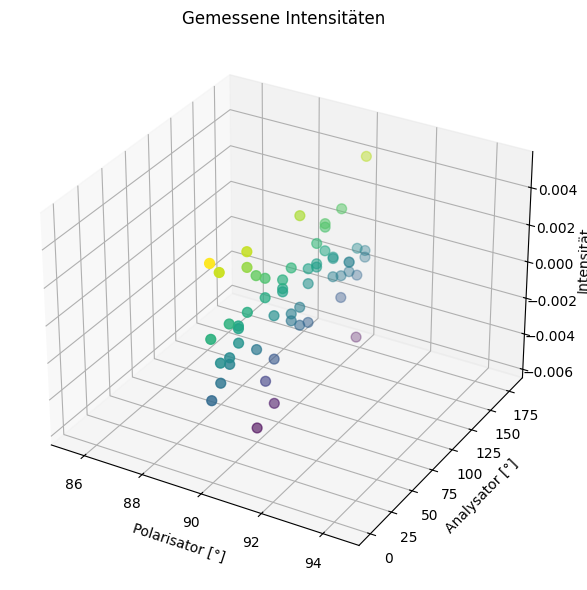


Rekonstruierte 3x3-Matrix:
[[-1.76352104e-04  1.76352104e-04  8.84600331e-20]
 [ 2.45704752e-04 -2.45704752e-04  3.00901538e-20]
 [ 1.88462278e-04 -1.88462278e-04  2.30799726e-20]]

Normierte Matrix:
[[ 1.00000000e+00 -1.00000000e+00 -5.01610307e-16]
 [-1.39326238e+00  1.39326238e+00 -1.70625431e-16]
 [-1.06867042e+00  1.06867042e+00 -1.30874382e-16]]
Ursprüngliche Probenmatrix:
[[ 0.8   0.1   0.05  0.02]
 [ 0.08  0.55  0.1   0.03]
 [ 0.04  0.12  0.45 -0.08]
 [ 0.01  0.02  0.1   0.35]]

Rang des Gleichungssystems: 3
Fertig.


In [5]:
# ============================================================
# 12. Hauptprogramm
# ============================================================

if __name__ == "__main__":

    print("=" * 60)
    print("MÜLLER-MATRIX-MESSUNG")
    print("=" * 60)

    print(f"Laserwellenlänge: {WAVELENGTH * 1e9:.0f} nm")

    # --------------------------------------------------------
    # Winkel einstellen
    # --------------------------------------------------------

    # Mehrere Polarisatorstellungen
    polarizer_angles = np.array([90, 90, 90]
    )

    # Mehrere Analysatorstellungen
    analyzer_angles = np.array(
        [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 180]
    )

    print(
        f"Polarisatorwinkel: {len(polarizer_angles)}"
    )

    print(
        f"Analysatorwinkel: {len(analyzer_angles)}"
    )

    print(
        f"Anzahl Messungen: "
        f"{len(polarizer_angles) * len(analyzer_angles)}"
    )

    # --------------------------------------------------------
    # Beispiel-Probe
    # --------------------------------------------------------

    M_true = example_sample_matrix()

    print("Ursprüngliche Probenmatrix:")
    print(M_true)

    # --------------------------------------------------------
    # Messungen simulieren
    # --------------------------------------------------------

    measurements = generate_measurements(
        M_true,
        polarizer_angles,
        analyzer_angles,
        noise_std=0.002
    )

    # --------------------------------------------------------
    # Messdaten speichern
    # --------------------------------------------------------

    save_measurements(
        "mueller_measurements.csv",
        measurements
    )

    print(
        "\nMessdaten gespeichert als:"
        " mueller_measurements.csv"
    )

    # --------------------------------------------------------
    # Messdaten darstellen
    # --------------------------------------------------------

    plot_measurements(measurements)

    # --------------------------------------------------------
    # Müller-Matrix rekonstruieren
    # --------------------------------------------------------

    M_reconstructed, residuals, rank = \
        reconstruct_mueller_matrix(measurements)

    print("\nRekonstruierte 3x3-Matrix:")
    print(M_reconstructed)

    # --------------------------------------------------------
    # Normierung
    # --------------------------------------------------------

    M_normalized = normalize_matrix(
        M_reconstructed
    )

    print("\nNormierte Matrix:")
    print(M_normalized)
    print("Ursprüngliche Probenmatrix:")
    print(M_true)

    print("\nRang des Gleichungssystems:", rank)

    if len(residuals) > 0:
        print(
            "Summe der quadratischen Residuen:",
            residuals[0]
        )

    print("Fertig.")


Stokes-Vektor vor der Probe (nach QWP): [0.5 0.  0.  0.5]
Stokes-Vektor nach der Probe:           [ 0.5    -0.2783  0.3317  0.25  ]


FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/intensitaet_vs_analysator.png'

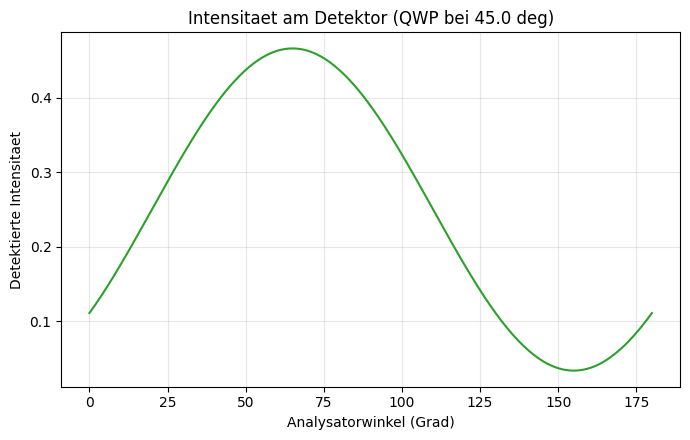

In [ ]:
"""
Mueller-Polarimetrie Simulation
================================

Aufbau:
    Grüner Laser -> fester Polarisator (0 Grad) -> lambda/4-Plaettchen (Winkel frei waehlbar)
    -> Probe (beliebige Mueller-Matrix) -> variabler Polarisator (Analysator)

Konventionen:
    - Stokes-Vektor S = (S0, S1, S2, S3)
        S0 = Gesamtintensitaet
        S1 = horizontal(+)/vertikal(-) linear polarisierter Anteil
        S2 = +45 grad/-45 grad linear polarisierter Anteil
        S3 = rechts(+)/links(-) zirkular polarisierter Anteil
    - Winkel in Radiant intern, Eingaben in Grad
    - Mueller-Matrizen nach der ueblichen Definition (siehe z.B. Goldstein,
      "Polarized Light")

Physikalische Einschraenkung des Aufbaus:
    Ein linearer Analysator am Ausgang misst nur

        I(theta_a) = 0.5 * (S0 + S1*cos(2 theta_a) + S2*sin(2 theta_a))

    Das heisst: S3 (zirkularer Anteil) NACH der Probe ist mit diesem Aufbau
    NICHT messbar. Fuer eine vollstaendige 4x4 Mueller-Matrix-Rekonstruktion
    der Probe braeuchte man zusaetzlich ein zweites lambda/4-Plaettchen VOR
    dem Analysator (klassischer "dual rotating retarder" Polarimeter-Aufbau).
    Das wird im Code unten explizit sichtbar gemacht.
"""

import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------------------------------------------
# Grundbausteine der Mueller-Rechnung
# ----------------------------------------------------------------------

def deg2rad(deg):
    return np.deg2rad(deg)


def mueller_rotation(theta_rad):
    """Rotationsmatrix im Mueller-Formalismus (dreht das Bezugssystem)."""
    c2 = np.cos(2 * theta_rad)
    s2 = np.sin(2 * theta_rad)
    return np.array([
        [1, 0,   0,  0],
        [0, c2,  s2, 0],
        [0, -s2, c2, 0],
        [0, 0,   0,  1],
    ])


def mueller_linear_polarizer(theta_deg, Tmax=1.0, Tmin=0.0):
    """
    Linearer Polarisator mit Durchlassachse bei theta_deg.
    Tmax/Tmin erlauben einen nicht-idealen (realen) Polarisator.
    """
    theta = deg2rad(theta_deg)
    A = 0.5 * (Tmax + Tmin)
    B = 0.5 * (Tmax - Tmin)
    C = np.sqrt(Tmax * Tmin)
    M0 = np.array([
        [A, B, 0, 0],
        [B, A, 0, 0],
        [0, 0, C, 0],
        [0, 0, 0, C],
    ])
    R = mueller_rotation(theta)
    Rm = mueller_rotation(-theta)
    return Rm @ M0 @ R


def mueller_retarder(theta_deg, delta_deg):
    """
    Allgemeine Verzoegerungsplatte (Waveplate) mit schneller Achse bei
    theta_deg und Phasenverzoegerung delta_deg.
    delta = 90 grad  -> lambda/4-Plaettchen
    delta = 180 grad -> lambda/2-Plaettchen
    """
    theta = deg2rad(theta_deg)
    delta = deg2rad(delta_deg)
    c = np.cos(delta)
    s = np.sin(delta)
    M0 = np.array([
        [1, 0, 0,  0],
        [0, 1, 0,  0],
        [0, 0, c,  s],
        [0, 0, -s, c],
    ])
    R = mueller_rotation(theta)
    Rm = mueller_rotation(-theta)
    return Rm @ M0 @ R


def mueller_depolarizer(d1=1.0, d2=1.0, d3=1.0):
    """Idealer Depolarisator: reduziert S1,S2,S3 um Faktoren d1,d2,d3 <= 1."""
    return np.diag([1.0, d1, d2, d3])


def mueller_optical_rotator(alpha_deg):
    """
    Optisch aktives Medium (z.B. Zuckerloesung): dreht die lineare
    Polarisationsebene um alpha_deg, ohne die Elliptizitaet zu aendern.
    Formal identisch zur Mueller-Rotationsmatrix.
    """
    return mueller_rotation(deg2rad(alpha_deg))


# ----------------------------------------------------------------------
# Beispiel-Proben (frei anpassbar / kombinierbar)
# ----------------------------------------------------------------------

def probe_identitaet():
    return np.eye(4)


def probe_linearer_diattenuator(theta_deg=30, Tmax=1.0, Tmin=0.3):
    """z.B. leicht dichroitische Probe."""
    return mueller_linear_polarizer(theta_deg, Tmax, Tmin)


def probe_verzoegerungsplatte(theta_deg=20, delta_deg=60):
    """z.B. spannungsdoppelbrechende Probe / Kristall."""
    return mueller_retarder(theta_deg, delta_deg)


def probe_optisch_aktiv_plus_depol(alpha_deg=25, d=0.9):
    """z.B. Zuckerloesung mit leichter Streuung/Depolarisation."""
    return mueller_depolarizer(d, d, d) @ mueller_optical_rotator(alpha_deg)


# ----------------------------------------------------------------------
# Optischer Aufbau: Quelle -> fester Polarisator -> QWP -> Probe -> Analysator
# ----------------------------------------------------------------------

def eingangszustand(I0, fester_polarisator_deg, qwp_winkel_deg):
    """
    Stokes-Vektor direkt nach dem lambda/4-Plaettchen, also der Zustand,
    der auf die Probe trifft (Polarization State Generator, PSG).
    """
    S_quelle = np.array([I0, 0, 0, 0])  # unpolarisierter gruener Laser
    M_pol = mueller_linear_polarizer(fester_polarisator_deg)
    M_qwp = mueller_retarder(qwp_winkel_deg, 90.0)
    return M_qwp @ M_pol @ S_quelle


def intensitaet_am_detektor(S_vor_analysator, analysator_deg):
    """Intensitaet nach dem variablen Analysator (Malus-artig, verallgemeinert)."""
    M_an = mueller_linear_polarizer(analysator_deg)
    S_out = M_an @ S_vor_analysator
    return S_out[0]


def simuliere_kurve(I0, fester_polarisator_deg, qwp_winkel_deg, M_probe,
                     analysator_winkel_liste_deg):
    S_ein = eingangszustand(I0, fester_polarisator_deg, qwp_winkel_deg)
    S_nach_probe = M_probe @ S_ein
    I = np.array([
        intensitaet_am_detektor(S_nach_probe, a)
        for a in analysator_winkel_liste_deg
    ])
    return I, S_ein, S_nach_probe


# ----------------------------------------------------------------------
# Teil-Rekonstruktion von S0, S1, S2 nach der Probe (S3 nicht zugaenglich!)
# ----------------------------------------------------------------------

def rekonstruiere_S0_S1_S2(analysator_winkel_deg, I_gemessen):
    """
    Fit von I(theta_a) = A + B*cos(2 theta_a) + C*sin(2 theta_a)
    liefert S0 = 2A, S1 = 2B, S2 = 2C.
    S3 kann mit einem einzelnen linearen Analysator NICHT bestimmt werden.
    """
    theta = deg2rad(np.asarray(analysator_winkel_deg))
    X = np.column_stack([
        np.ones_like(theta),
        np.cos(2 * theta),
        np.sin(2 * theta),
    ])
    coeffs, *_ = np.linalg.lstsq(X, I_gemessen, rcond=None)
    A, B, C = coeffs
    return np.array([2 * A, 2 * B, 2 * C])  # S0, S1, S2


# ----------------------------------------------------------------------
# Demo / Hauptprogramm
# ----------------------------------------------------------------------

if __name__ == "__main__":

    I0 = 1.0
    FESTER_POLARISATOR = 0.0      # Grad
    QWP_WINKEL = 45.0             # Grad, erzeugt bei 45 grad zirkulare Pol.

    # Probe auswaehlen (einfach eine der Beispielfunktionen nutzen):
    M_probe = probe_verzoegerungsplatte(theta_deg=20, delta_deg=60)
    # Alternativen zum Ausprobieren:
    # M_probe = probe_identitaet()
    # M_probe = probe_linearer_diattenuator(theta_deg=30, Tmax=1.0, Tmin=0.3)
    # M_probe = probe_optisch_aktiv_plus_depol(alpha_deg=25, d=0.9)

    analysator_winkel = np.linspace(0, 180, 361)

    I_signal, S_ein, S_nach_probe = simuliere_kurve(
        I0, FESTER_POLARISATOR, QWP_WINKEL, M_probe, analysator_winkel
    )

    print("Stokes-Vektor vor der Probe (nach QWP):", np.round(S_ein, 4))
    print("Stokes-Vektor nach der Probe:          ", np.round(S_nach_probe, 4))

    # --- Plot 1: gemessene Intensitaet vs. Analysatorwinkel -----------
    fig1, ax1 = plt.subplots(figsize=(7, 4.5))
    ax1.plot(analysator_winkel, I_signal, color="tab:green")
    ax1.set_xlabel("Analysatorwinkel (Grad)")
    ax1.set_ylabel("Detektierte Intensitaet")
    ax1.set_title(f"Intensitaet am Detektor (QWP bei {QWP_WINKEL} deg)")
    ax1.grid(alpha=0.3)
    fig1.tight_layout()
    fig1.savefig("/outputs/intensitaet_vs_analysator.png", dpi=150)

    # --- Rekonstruktion S0,S1,S2 aus der Kurve prüfen ------------------
    S_rek = rekonstruiere_S0_S1_S2(analysator_winkel, I_signal)
    print("\nAus der Analysator-Kurve rekonstruiert (S3 nicht bestimmbar):")
    print("  S0, S1, S2 (rekonstruiert):", np.round(S_rek, 4))
    print("  S0, S1, S2 (exakt, Simulation):", np.round(S_nach_probe[:3], 4))
    print("  S3 (exakt, aber mit diesem Aufbau NICHT messbar):",
          round(S_nach_probe[3], 4))

    # --- Plot 2: Karte Intensitaet(QWP-Winkel, Analysatorwinkel) ------
    qwp_winkel_liste = np.linspace(0, 180, 91)
    I_map = np.zeros((len(qwp_winkel_liste), len(analysator_winkel)))
    for i, qwp_w in enumerate(qwp_winkel_liste):
        I_map[i, :], _, _ = simuliere_kurve(
            I0, FESTER_POLARISATOR, qwp_w, M_probe, analysator_winkel
        )

    fig2, ax2 = plt.subplots(figsize=(7, 5.5))
    im = ax2.imshow(
        I_map, origin="lower", aspect="auto", cmap="viridis",
        extent=[analysator_winkel.min(), analysator_winkel.max(),
                qwp_winkel_liste.min(), qwp_winkel_liste.max()],
    )
    ax2.set_xlabel("Analysatorwinkel (Grad)")
    ax2.set_ylabel("lambda/4-Plaettchen Winkel (Grad)")
    ax2.set_title("Detektierte Intensitaet als Funktion beider Winkel")
    fig2.colorbar(im, ax=ax2, label="Intensitaet")
    fig2.tight_layout()
    fig2.savefig("/outputs/intensitaetskarte.png", dpi=150)

    print("\nPlots gespeichert:")
    print("  intensitaet_vs_analysator.png")
    print("  intensitaetskarte.png")


Wahre Mueller-Matrix der Probe:
[[ 0.7     0.2598  0.15    0.    ]
 [-0.1071 -0.2021 -0.15   -0.556 ]
 [ 0.0759 -0.1158  0.5547 -0.0929]
 [ 0.2252  0.5414  0.1131 -0.1839]]


FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/intensitaet_vs_theta1.png'

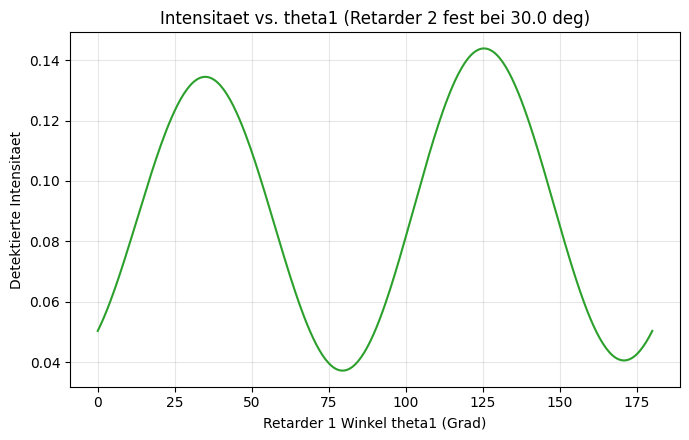

In [1]:
"""
Mueller-Polarimetrie: Dual-Rotating-Retarder Aufbau
=====================================================

Aufbau:
    Laser -> fester Polarisator -> variabler Retarder (PSG, Winkel theta1)
    -> Probe -> variabler Retarder (PSA, Winkel theta2) -> fester Polarisator
    -> Detektor

Das ist der klassische "Dual Rotating Retarder" Mueller-Matrix-Polarimeter
(Azzam 1978). Im Unterschied zum vorherigen Aufbau (fester Analysator-
Polarisator war variabel, kein zweiter Retarder) ist hier sowohl vor als
auch nach der Probe ein Retarder vorhanden. Dadurch werden auch zirkulare
Polarisationsanteile (S3) am Eingang UND Ausgang zugaenglich, und die
GESAMTE 4x4-Mueller-Matrix der Probe (16 Elemente) kann rekonstruiert
werden -- nicht nur S0, S1, S2 wie im reinen Analysator-Aufbau.

Methode zur Rekonstruktion:
    Fuer jede Messung k mit Retarderwinkeln (theta1_k, theta2_k) gilt

        I_k = a_k^T * M_probe * s_k

    wobei
        s_k = Stokes-Vektor unmittelbar vor der Probe (haengt von theta1_k ab)
        a_k = "Analysevektor" = erste Zeile von (M_pol_aus @ M_ret2(theta2_k))

    Das ist LINEAR in den 16 unbekannten Eintraegen von M_probe. Wir messen
    also viele (theta1, theta2)-Kombinationen, bauen ein grosses lineares
    Gleichungssystem auf und loesen es per kleinste-Quadrate (numpy.lstsq).
    Das ist aequivalent zum klassischen Fourier-Verfahren mit synchronisierter
    5:1-Rotation, aber direkter und ohne auswendig gelernte Formeln.
"""

import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------------------------------------------
# Grundbausteine (wie zuvor)
# ----------------------------------------------------------------------

def deg2rad(deg):
    return np.deg2rad(deg)


def mueller_rotation(theta_rad):
    c2 = np.cos(2 * theta_rad)
    s2 = np.sin(2 * theta_rad)
    return np.array([
        [1, 0,   0,  0],
        [0, c2,  s2, 0],
        [0, -s2, c2, 0],
        [0, 0,   0,  1],
    ])


def mueller_linear_polarizer(theta_deg, Tmax=1.0, Tmin=0.0):
    theta = deg2rad(theta_deg)
    A = 0.5 * (Tmax + Tmin)
    B = 0.5 * (Tmax - Tmin)
    C = np.sqrt(Tmax * Tmin)
    M0 = np.array([
        [A, B, 0, 0],
        [B, A, 0, 0],
        [0, 0, C, 0],
        [0, 0, 0, C],
    ])
    R = mueller_rotation(theta)
    Rm = mueller_rotation(-theta)
    return Rm @ M0 @ R


def mueller_retarder(theta_deg, delta_deg):
    theta = deg2rad(theta_deg)
    delta = deg2rad(delta_deg)
    c = np.cos(delta)
    s = np.sin(delta)
    M0 = np.array([
        [1, 0, 0,  0],
        [0, 1, 0,  0],
        [0, 0, c,  s],
        [0, 0, -s, c],
    ])
    R = mueller_rotation(theta)
    Rm = mueller_rotation(-theta)
    return Rm @ M0 @ R


def mueller_depolarizer(d1=1.0, d2=1.0, d3=1.0):
    return np.diag([1.0, d1, d2, d3])


def mueller_optical_rotator(alpha_deg):
    return mueller_rotation(deg2rad(alpha_deg))


# ----------------------------------------------------------------------
# Beispiel-Proben
# ----------------------------------------------------------------------

def probe_identitaet():
    return np.eye(4)


def probe_linearer_diattenuator(theta_deg=30, Tmax=1.0, Tmin=0.3):
    return mueller_linear_polarizer(theta_deg, Tmax, Tmin)


def probe_verzoegerungsplatte(theta_deg=20, delta_deg=60):
    return mueller_retarder(theta_deg, delta_deg)


def probe_optisch_aktiv_plus_depol(alpha_deg=25, d=0.9):
    return mueller_depolarizer(d, d, d) @ mueller_optical_rotator(alpha_deg)


def probe_komplex_beispiel():
    """Kombination aus Diattenuation, Retardanz und leichter Depolarisation,
    damit alle 16 Matrixelemente ungleich trivial sind -- gut zum Testen
    der vollen Rekonstruktion."""
    M_diatt = mueller_linear_polarizer(theta_deg=15, Tmax=1.0, Tmin=0.4)
    M_ret = mueller_retarder(theta_deg=50, delta_deg=110)
    M_depol = mueller_depolarizer(0.95, 0.9, 0.85)
    return M_depol @ M_ret @ M_diatt


# ----------------------------------------------------------------------
# Optischer Aufbau: Laser -> Pol -> Retarder1(theta1) -> Probe
#                    -> Retarder2(theta2) -> Pol -> Detektor
# ----------------------------------------------------------------------

RETARDANZ_DEG = 90.0  # 90 = lambda/4. Reale Dual-Rotating-Retarder-Polarimeter
                       # nutzen oft ~127-132 Grad fuer bessere Konditionierung,
                       # hier frei einstellbar.


def eingangszustand(I0, pol_ein_deg, theta1_deg, retardanz_deg=RETARDANZ_DEG):
    """Stokes-Vektor unmittelbar vor der Probe."""
    S_quelle = np.array([I0, 0, 0, 0])
    M_pol = mueller_linear_polarizer(pol_ein_deg)
    M_ret1 = mueller_retarder(theta1_deg, retardanz_deg)
    return M_ret1 @ M_pol @ S_quelle


def analysevektor(pol_aus_deg, theta2_deg, retardanz_deg=RETARDANZ_DEG):
    """
    Erste Zeile von (M_pol_aus @ M_ret2(theta2)) -- der Vektor a_k, mit dem
    man den Stokes-Vektor nach der Probe multipliziert, um die am Detektor
    gemessene Intensitaet zu erhalten: I = a_k . S_nach_probe
    """
    M_pol = mueller_linear_polarizer(pol_aus_deg)
    M_ret2 = mueller_retarder(theta2_deg, retardanz_deg)
    return (M_pol @ M_ret2)[0, :]


def intensitaet(I0, pol_ein_deg, pol_aus_deg, theta1_deg, theta2_deg,
                M_probe, retardanz_deg=RETARDANZ_DEG):
    s_in = eingangszustand(I0, pol_ein_deg, theta1_deg, retardanz_deg)
    a = analysevektor(pol_aus_deg, theta2_deg, retardanz_deg)
    S_nach_probe = M_probe @ s_in
    return float(a @ S_nach_probe)


# ----------------------------------------------------------------------
# Volle 16-Element Mueller-Matrix-Rekonstruktion
# ----------------------------------------------------------------------

def rekonstruiere_mueller_matrix(I0, pol_ein_deg, pol_aus_deg,
                                  theta1_liste_deg, theta2_liste_deg,
                                  M_probe_wahr, retardanz_deg=RETARDANZ_DEG):
    """
    Rastert alle Kombinationen aus theta1_liste_deg x theta2_liste_deg ab,
    simuliert die Intensitaet (= 'Messung') und loest anschliessend das
    lineare Gleichungssystem I_k = a_k^T M s_k nach den 16 Eintraegen von
    M_probe per kleinste Quadrate.
    """
    W_rows = []
    I_meas = []

    for th1 in theta1_liste_deg:
        s_in = eingangszustand(I0, pol_ein_deg, th1, retardanz_deg)
        for th2 in theta2_liste_deg:
            a = analysevektor(pol_aus_deg, th2, retardanz_deg)
            # Koeffizientenvektor: coeff[i*4+j] = a[i] * s_in[j]
            coeff = np.outer(a, s_in).flatten()  # Reihenfolge passt zu M.flatten()
            W_rows.append(coeff)

            S_nach_probe = M_probe_wahr @ s_in
            I_meas.append(float(a @ S_nach_probe))

    W = np.array(W_rows)          # (N_messungen, 16)
    I_meas = np.array(I_meas)     # (N_messungen,)

    M_flat, residuals, rank, sing_vals = np.linalg.lstsq(W, I_meas, rcond=None)
    M_rekonstruiert = M_flat.reshape(4, 4)

    kondition = sing_vals.max() / sing_vals.min() if sing_vals.min() > 0 else np.inf

    return M_rekonstruiert, rank, kondition


# ----------------------------------------------------------------------
# Demo / Hauptprogramm
# ----------------------------------------------------------------------

if __name__ == "__main__":

    I0 = 1.0
    POL_EIN = 0.0     # fester Polarisator vor Retarder1, Grad
    POL_AUS = 0.0     # fester Polarisator nach Retarder2 (Analysator), Grad

    # ---- Probe waehlen -------------------------------------------------
    M_probe = probe_komplex_beispiel()
    # Alternativen:
    # M_probe = probe_identitaet()
    # M_probe = probe_linearer_diattenuator(30, 1.0, 0.3)
    # M_probe = probe_verzoegerungsplatte(20, 60)
    # M_probe = probe_optisch_aktiv_plus_depol(25, 0.9)

    print("Wahre Mueller-Matrix der Probe:")
    print(np.round(M_probe, 4))

    # ---- Plot 1: Intensitaet vs theta1 bei festem theta2 ---------------
    theta1_scan = np.linspace(0, 180, 361)
    theta2_fest = 30.0
    I_scan = [intensitaet(I0, POL_EIN, POL_AUS, t1, theta2_fest, M_probe)
              for t1 in theta1_scan]

    fig1, ax1 = plt.subplots(figsize=(7, 4.5))
    ax1.plot(theta1_scan, I_scan, color="tab:green")
    ax1.set_xlabel("Retarder 1 Winkel theta1 (Grad)")
    ax1.set_ylabel("Detektierte Intensitaet")
    ax1.set_title(f"Intensitaet vs. theta1 (Retarder 2 fest bei {theta2_fest} deg)")
    ax1.grid(alpha=0.3)
    fig1.tight_layout()
    fig1.savefig("/mnt/user-data/outputs/intensitaet_vs_theta1.png", dpi=150)

    # ---- Plot 2: Intensitaetskarte ueber theta1 und theta2 -------------
    theta1_grid = np.linspace(0, 180, 91)
    theta2_grid = np.linspace(0, 180, 91)
    I_map = np.zeros((len(theta1_grid), len(theta2_grid)))
    for i, t1 in enumerate(theta1_grid):
        for j, t2 in enumerate(theta2_grid):
            I_map[i, j] = intensitaet(I0, POL_EIN, POL_AUS, t1, t2, M_probe)

    fig2, ax2 = plt.subplots(figsize=(7, 5.5))
    im = ax2.imshow(
        I_map, origin="lower", aspect="auto", cmap="viridis",
        extent=[theta2_grid.min(), theta2_grid.max(),
                theta1_grid.min(), theta1_grid.max()],
    )
    ax2.set_xlabel("Retarder 2 Winkel theta2 (Grad)")
    ax2.set_ylabel("Retarder 1 Winkel theta1 (Grad)")
    ax2.set_title("Detektierte Intensitaet I(theta1, theta2)")
    fig2.colorbar(im, ax=ax2, label="Intensitaet")
    fig2.tight_layout()
    fig2.savefig("/mnt/user-data/outputs/intensitaetskarte_dual_retarder.png", dpi=150)

    # ---- Volle Mueller-Matrix-Rekonstruktion ---------------------------
    theta1_liste = np.linspace(0, 180, 20, endpoint=False)
    theta2_liste = np.linspace(0, 180, 20, endpoint=False)

    M_rek, rang, kondition = rekonstruiere_mueller_matrix(
        I0, POL_EIN, POL_AUS, theta1_liste, theta2_liste, M_probe
    )

    print("\nRekonstruierte Mueller-Matrix der Probe:")
    print(np.round(M_rek, 4))

    print("\nAbweichung (rekonstruiert - wahr):")
    print(np.round(M_rek - M_probe, 6))

    print(f"\nRang des Gleichungssystems: {rang} (von 16 moeglich)")
    print(f"Konditionszahl: {kondition:.2f}  "
          f"(kleiner = numerisch stabiler; >>1e4 deutet auf schlechte "
          f"Winkelwahl/Retardanz hin)")

    max_fehler = np.max(np.abs(M_rek - M_probe))
    print(f"\nMax. absoluter Fehler pro Element: {max_fehler:.2e}")

    print("\nPlots gespeichert:")
    print("  intensitaet_vs_theta1.png")
    print("  intensitaetskarte_dual_retarder.png")


Bild: 128x128 = 16384 Gewebe-Pixel
  Transmission  : 0.25 .. 1.00
  Diattenuation : 0.00 .. 0.35
  Retardanz     : 0.0 .. 150.0 Grad
  Depolarisation: Faktor 0.55 .. 0.98

Messmatrix: 256 Messungen, Konditionszahl 3.8
Max. Rekonstruktionsfehler (Matrixelemente): 1.67e-15

Rueckgewinnung der Gewebeparameter (Lu-Chipman):
  Retardanz  : mittl. Fehler 0.000 Grad
  Achse      : mittl. Fehler 0.000 Grad  (nur Pixel mit Retardanz > 10 Grad)
  Depol.grad : mittl. Fehler 0.0000


FileNotFoundError: [Errno 2] No such file or directory: 'outputs/gewebe_parameterkarten.png'

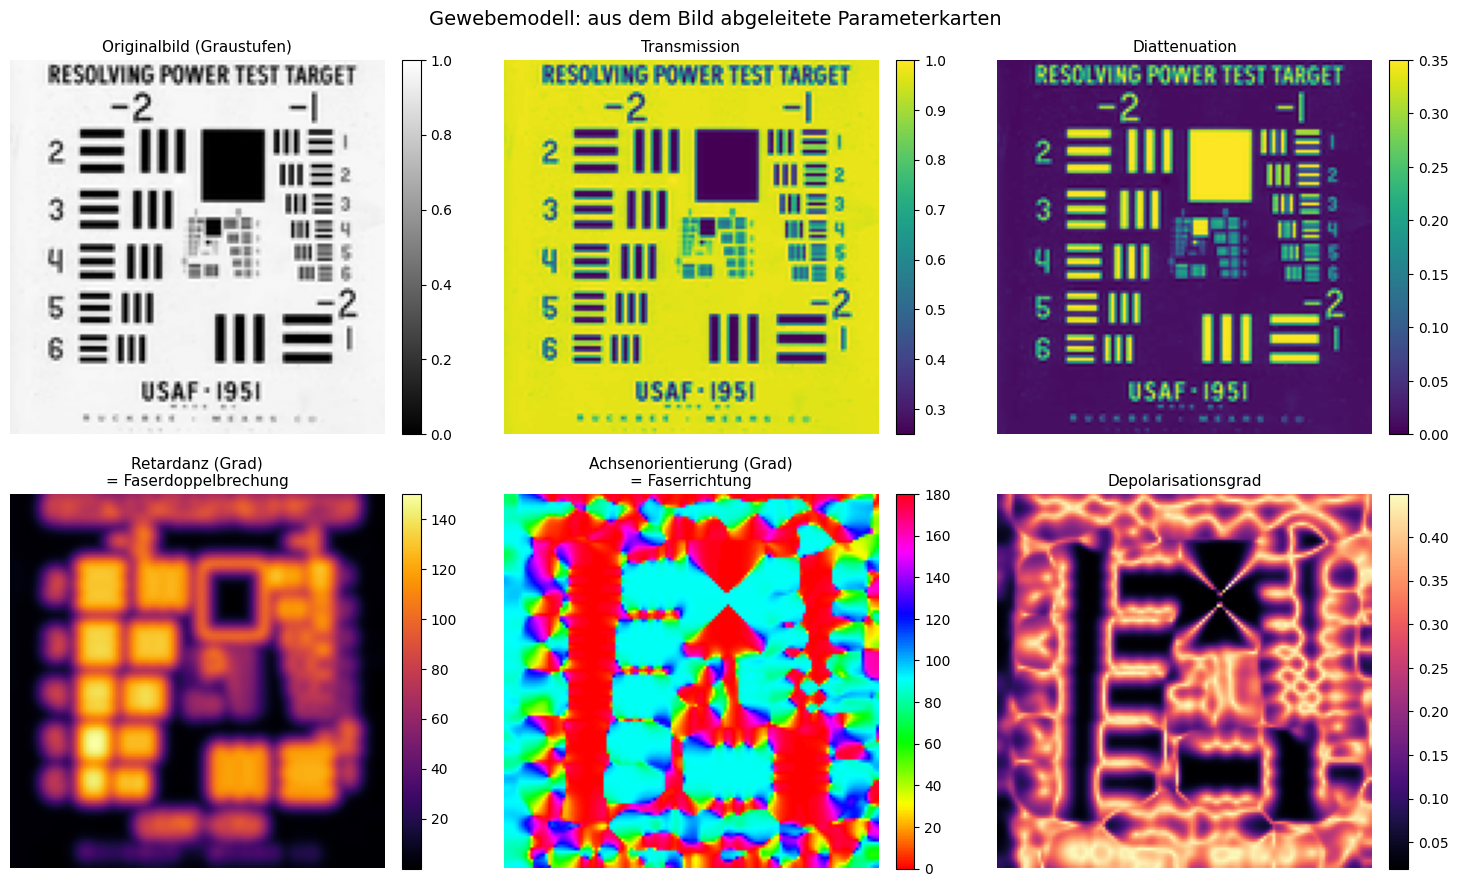

In [6]:
"""
Mueller-Polarimetrie: Emulation von biologischem Gewebe
=========================================================

Aufbau (Dual-Rotating-Retarder-Polarimeter):
    Laser -> fester Polarisator -> variabler Retarder (theta1)
    -> Gewebeprobe (pixelweise) -> variabler Retarder (theta2)
    -> fester Polarisator -> Detektor

GEWEBEMODELL
------------
Biologisches Gewebe zeigt typischerweise DREI gleichzeitig wirkende
polarisationsoptische Effekte, die hier alle aus dem Bild abgeleitet werden:

  1) Diattenuation / Transmission
     Absorption und Streuverlust. Dichte Strukturen transmittieren weniger.
     -> aus dem Grauwert direkt.

  2) Lineare Doppelbrechung (Retardanz delta)
     Entsteht durch AUSGERICHTETE Kollagen- bzw. Muskelfasern. Die Staerke
     der Doppelbrechung korreliert mit der lokalen Strukturstaerke.
     -> aus der Gradientenstaerke (Strukturtensor).

  3) Orientierung der schnellen Achse (theta)
     Entspricht der lokalen FASERRICHTUNG. Fasern verlaufen ENTLANG von
     Strukturkanten, der Bildgradient steht SENKRECHT dazu.
     -> aus der Gradientenrichtung + 90 Grad.

  Zusaetzlich: Depolarisation
     Vielfachstreuung in ungeordnetem Gewebe zerstoert Polarisation.
     Geordnete Faserbuendel erhalten sie besser.
     -> aus der Kohaerenz des Strukturtensors (hohe Ordnung = wenig Depol.).

Reihenfolge im Gewebemodell (Lu-Chipman-Konvention):
    M_gewebe = M_Depolarisator @ M_Retarder @ M_Diattenuator

AUSWERTUNG
----------
Nach der pixelweisen Rekonstruktion der 16 Matrixelemente wird die
LU-CHIPMAN-POLARZERLEGUNG angewandt, um aus jeder rekonstruierten Matrix
die physikalischen Gewebeparameter zurueckzugewinnen:
    M = M_Delta @ M_R @ M_D
        -> Diattenuation D, Retardanz delta, Achsenorientierung theta,
           Depolarisationsgrad Delta
Das ist genau der Auswerteschritt, der in der realen Gewebepolarimetrie
verwendet wird (Lu & Chipman, JOSA A 13, 1106, 1996).
"""

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy.ndimage import gaussian_filter, sobel

# ======================================================================
# TEIL 1: Mueller-Grundbausteine
# ======================================================================

def deg2rad(deg):
    return np.deg2rad(deg)


def mueller_rotation(theta_rad):
    c2 = np.cos(2 * theta_rad)
    s2 = np.sin(2 * theta_rad)
    return np.array([
        [1, 0,   0,  0],
        [0, c2,  s2, 0],
        [0, -s2, c2, 0],
        [0, 0,   0,  1],
    ])


def mueller_linear_polarizer(theta_deg, Tmax=1.0, Tmin=0.0):
    theta = deg2rad(theta_deg)
    A = 0.5 * (Tmax + Tmin)
    B = 0.5 * (Tmax - Tmin)
    C = np.sqrt(Tmax * Tmin)
    M0 = np.array([
        [A, B, 0, 0],
        [B, A, 0, 0],
        [0, 0, C, 0],
        [0, 0, 0, C],
    ])
    R = mueller_rotation(theta)
    Rm = mueller_rotation(-theta)
    return Rm @ M0 @ R


def mueller_retarder(theta_deg, delta_deg):
    theta = deg2rad(theta_deg)
    delta = deg2rad(delta_deg)
    c = np.cos(delta)
    s = np.sin(delta)
    M0 = np.array([
        [1, 0, 0,  0],
        [0, 1, 0,  0],
        [0, 0, c,  s],
        [0, 0, -s, c],
    ])
    R = mueller_rotation(theta)
    Rm = mueller_rotation(-theta)
    return Rm @ M0 @ R


# ======================================================================
# TEIL 2: Bild -> Gewebe-Parameterkarten
# ======================================================================

BILD_PFAD = "USAFcut.png"
ZIEL_GROESSE = 128

# --- Gewebeparameter-Bereiche (frei einstellbar) ---
TRANSMISSION_MIN = 0.25    # dunkelste Struktur laesst noch 25% durch
TRANSMISSION_MAX = 1.00    # heller Hintergrund: volle Transmission
DIATTENUATION_MAX = 0.35   # max. Diattenuation (Gewebe: typisch klein, <0.4)
RETARDANZ_MAX_DEG = 150.0  # max. lineare Doppelbrechung an Faserstrukturen
DEPOL_MIN = 0.55           # stark depolarisierendes, ungeordnetes Gewebe
DEPOL_MAX = 0.98           # geordnete Fasern: Polarisation bleibt erhalten
GLAETTUNG_SIGMA = 2.0      # Strukturtensor-Glaettung (Faserbuendel-Skala)


def lade_und_skaliere(pfad, groesse):
    img = Image.open(pfad).convert("L")
    img = img.resize((groesse, groesse), Image.LANCZOS)
    return np.asarray(img, dtype=np.float64) / 255.0


def strukturtensor(grau, sigma=GLAETTUNG_SIGMA):
    """
    Berechnet den lokalen Strukturtensor des Bildes.

    Rueckgabe:
        staerke     : Gradientenenergie (Jxx+Jyy), Mass fuer Strukturstaerke
        kohaerenz   : 0..1, wie stark die lokale Struktur gerichtet ist
        faserwinkel : lokale Faserrichtung in Grad (Kantenrichtung, also
                      senkrecht zum Gradienten)
    """
    # Bildgradienten
    gx = sobel(grau, axis=1, mode="reflect")
    gy = sobel(grau, axis=0, mode="reflect")

    # Strukturtensor-Komponenten, ueber die Faserbuendel-Skala geglaettet
    Jxx = gaussian_filter(gx * gx, sigma)
    Jxy = gaussian_filter(gx * gy, sigma)
    Jyy = gaussian_filter(gy * gy, sigma)

    spur = Jxx + Jyy
    differenz = np.sqrt((Jxx - Jyy) ** 2 + 4.0 * Jxy ** 2)

    staerke = spur
    kohaerenz = differenz / (spur + 1e-12)   # 0 = isotrop, 1 = perfekt gerichtet

    # dominante GRADIENTEN-Richtung
    grad_winkel = 0.5 * np.arctan2(2.0 * Jxy, Jxx - Jyy)
    # Faserrichtung steht senkrecht dazu (Fasern laufen ENTLANG der Kante)
    faser_winkel_rad = grad_winkel + np.pi / 2.0

    return staerke, np.clip(kohaerenz, 0, 1), np.rad2deg(faser_winkel_rad)


def gewebe_parameterkarten(grau):
    """Leitet alle vier Gewebeparameter aus dem Graustufenbild ab."""
    staerke, kohaerenz, faser_winkel_deg = strukturtensor(grau)

    # --- 1) Transmission aus dem Grauwert ---
    transmission = TRANSMISSION_MIN + (TRANSMISSION_MAX - TRANSMISSION_MIN) * grau

    # --- 2) Diattenuation: dichte (dunkle) Strukturen sind dichroitischer ---
    diattenuation = DIATTENUATION_MAX * (1.0 - grau)

    # --- 3) Retardanz aus der Strukturstaerke (Faserdichte) ---
    staerke_norm = staerke / (staerke.max() + 1e-12)
    staerke_norm = np.sqrt(staerke_norm)  # Kontrast anheben
    retardanz_deg = RETARDANZ_MAX_DEG * staerke_norm

    # --- 4) Depolarisation: geordnete Fasern erhalten Polarisation ---
    depol = DEPOL_MIN + (DEPOL_MAX - DEPOL_MIN) * kohaerenz

    return {
        "transmission": transmission,
        "diattenuation": diattenuation,
        "retardanz_deg": retardanz_deg,
        "achse_deg": faser_winkel_deg,
        "depolarisation": depol,
        "kohaerenz": kohaerenz,
    }


# ======================================================================
# TEIL 3: Parameterkarten -> pixelweise Mueller-Matrizen (vektorisiert)
# ======================================================================

def baue_mueller_stapel(karten):
    """
    Baut fuer jedes Pixel M = M_Depol @ M_Retarder @ M_Diattenuator.
    Alles vektorisiert ueber N Pixel -> Ausgabe (N, 4, 4).
    """
    tau = karten["transmission"].flatten()
    D = karten["diattenuation"].flatten()
    delta = deg2rad(karten["retardanz_deg"].flatten())
    theta = deg2rad(karten["achse_deg"].flatten())
    d = karten["depolarisation"].flatten()
    N = tau.size

    # ---------- Diattenuator (lineare Diattenuation entlang Faserachse) ----
    # Tmax/Tmin aus D: D = (Tmax-Tmin)/(Tmax+Tmin), Gesamttransmission = tau
    Tmax = tau * (1.0 + D)
    Tmin = tau * (1.0 - D)
    A = 0.5 * (Tmax + Tmin)
    B = 0.5 * (Tmax - Tmin)
    C = np.sqrt(np.clip(Tmax * Tmin, 0, None))

    M_D0 = np.zeros((N, 4, 4))
    M_D0[:, 0, 0] = A
    M_D0[:, 0, 1] = B
    M_D0[:, 1, 0] = B
    M_D0[:, 1, 1] = A
    M_D0[:, 2, 2] = C
    M_D0[:, 3, 3] = C

    # ---------- Retarder (Achse theta, Verzoegerung delta) ----------------
    cd = np.cos(delta)
    sd = np.sin(delta)
    M_R0 = np.zeros((N, 4, 4))
    M_R0[:, 0, 0] = 1.0
    M_R0[:, 1, 1] = 1.0
    M_R0[:, 2, 2] = cd
    M_R0[:, 2, 3] = sd
    M_R0[:, 3, 2] = -sd
    M_R0[:, 3, 3] = cd

    # ---------- pixelweise Rotationsmatrizen (Achsenorientierung!) --------
    # Sowohl Diattenuator als auch Retarder werden auf die lokale
    # Faserachse theta gedreht: R(-theta) @ M0 @ R(theta)
    c2 = np.cos(2 * theta)
    s2 = np.sin(2 * theta)
    Rp = np.zeros((N, 4, 4))   # R(+theta)
    Rp[:, 0, 0] = 1.0
    Rp[:, 1, 1] = c2
    Rp[:, 1, 2] = s2
    Rp[:, 2, 1] = -s2
    Rp[:, 2, 2] = c2
    Rp[:, 3, 3] = 1.0

    Rm = np.zeros((N, 4, 4))   # R(-theta)
    Rm[:, 0, 0] = 1.0
    Rm[:, 1, 1] = c2
    Rm[:, 1, 2] = -s2
    Rm[:, 2, 1] = s2
    Rm[:, 2, 2] = c2
    Rm[:, 3, 3] = 1.0

    M_D = Rm @ M_D0 @ Rp
    M_R = Rm @ M_R0 @ Rp

    # ---------- Depolarisator (isotrop, Grad d) ---------------------------
    M_Delta = np.zeros((N, 4, 4))
    M_Delta[:, 0, 0] = 1.0
    M_Delta[:, 1, 1] = d
    M_Delta[:, 2, 2] = d
    M_Delta[:, 3, 3] = d

    # ---------- Gesamtmatrix ----------------------------------------------
    return M_Delta @ M_R @ M_D


# ======================================================================
# TEIL 4: Messmatrix des Polarimeters
# ======================================================================

RETARDANZ_PSG_PSA = 132.0   # Grad; ~132 statt 90 -> bessere Konditionierung
POL_EIN = 0.0
POL_AUS = 0.0
I0 = 1.0


def baue_messmatrix(theta1_liste, theta2_liste, retardanz=RETARDANZ_PSG_PSA):
    """Design-Matrix W: haengt NUR von den Retarderwinkeln ab, nicht vom Pixel."""
    zeilen = []
    M_pol_ein = mueller_linear_polarizer(POL_EIN)
    M_pol_aus = mueller_linear_polarizer(POL_AUS)
    S_quelle = np.array([I0, 0, 0, 0])

    for th1 in theta1_liste:
        s_in = mueller_retarder(th1, retardanz) @ M_pol_ein @ S_quelle
        for th2 in theta2_liste:
            a = (M_pol_aus @ mueller_retarder(th2, retardanz))[0, :]
            zeilen.append(np.outer(a, s_in).flatten())
    return np.array(zeilen)


# ======================================================================
# TEIL 5: Lu-Chipman-Polarzerlegung (vektorisiert ueber alle Pixel)
# ======================================================================

def lu_chipman_zerlegung(M):
    """
    Zerlegt einen Stapel von Mueller-Matrizen M (N,4,4) gemaess
        M = M_Delta @ M_R @ M_D
    und gibt die physikalischen Gewebeparameter zurueck.

    Rueckgabe (jeweils Arrays der Laenge N):
        D_betrag      : Diattenuation 0..1
        retardanz_deg : skalare Retardanz 0..180 Grad
        achse_deg     : Orientierung der schnellen Achse 0..180 Grad
        depol_grad    : Depolarisationsgrad 0 (keine) .. 1 (total)
        transmission  : M00
    """
    N = M.shape[0]
    m00 = M[:, 0, 0]
    m00_safe = np.where(np.abs(m00) < 1e-12, 1e-12, m00)

    # ---------- Schritt 1: Diattenuationsvektor ----------
    Dvec = M[:, 0, 1:] / m00_safe[:, None]          # (N,3)
    D_betrag = np.linalg.norm(Dvec, axis=1)
    D_betrag = np.clip(D_betrag, 0, 1 - 1e-9)

    # ---------- Schritt 2: Diattenuator-Matrix M_D aufbauen ----------
    D_hat = Dvec / (D_betrag[:, None] + 1e-12)
    wurzel = np.sqrt(1.0 - D_betrag ** 2)
    I3 = np.eye(3)[None, :, :]
    m_D = (wurzel[:, None, None] * I3
           + (1.0 - wurzel)[:, None, None] * np.einsum('ni,nj->nij', D_hat, D_hat))

    M_D = np.zeros((N, 4, 4))
    M_D[:, 0, 0] = 1.0
    M_D[:, 0, 1:] = Dvec
    M_D[:, 1:, 0] = Dvec
    M_D[:, 1:, 1:] = m_D
    M_D *= m00_safe[:, None, None]

    # ---------- Schritt 3: M' = M @ inv(M_D) ----------
    M_strich = M @ np.linalg.pinv(M_D)
    m_strich = M_strich[:, 1:, 1:]                   # (N,3,3)

    # ---------- Schritt 4: Depolarisator aus m' m'^T ----------
    mmT = m_strich @ np.transpose(m_strich, (0, 2, 1))
    eigw = np.linalg.eigvalsh(mmT)                   # aufsteigend, reell
    eigw = np.clip(eigw, 0, None)
    l1, l2, l3 = np.sqrt(eigw[:, 2]), np.sqrt(eigw[:, 1]), np.sqrt(eigw[:, 0])

    summe1 = l1 + l2 + l3
    summe2 = l1 * l2 + l2 * l3 + l3 * l1
    produkt = l1 * l2 * l3

    vorzeichen = np.sign(np.linalg.det(m_strich))
    vorzeichen[vorzeichen == 0] = 1.0

    lhs = mmT + summe2[:, None, None] * I3
    rhs = (summe1[:, None, None] * mmT + produkt[:, None, None] * I3)
    m_Delta = vorzeichen[:, None, None] * (np.linalg.pinv(lhs) @ rhs)

    spur_mDelta = np.trace(m_Delta, axis1=1, axis2=2)
    depol_grad = 1.0 - np.abs(spur_mDelta) / 3.0
    depol_grad = np.clip(depol_grad, 0, 1)

    # ---------- Schritt 5: Retarder m_R = inv(m_Delta) @ m' ----------
    m_R = np.linalg.pinv(m_Delta) @ m_strich

    spur_mR = np.trace(m_R, axis1=1, axis2=2)
    cos_R = np.clip((spur_mR - 1.0) / 2.0, -1.0, 1.0)
    retardanz_rad = np.arccos(cos_R)

    # ---------- Schritt 6: Achsenorientierung aus dem Retardanzvektor ----
    # a_i = 1/(2 sin R) * sum_jk eps_ijk (m_R)_jk
    sinR = np.sin(retardanz_rad)
    sinR_safe = np.where(np.abs(sinR) < 1e-9, 1e-9, sinR)
    a1 = (m_R[:, 1, 2] - m_R[:, 2, 1]) / (2.0 * sinR_safe)
    a2 = (m_R[:, 2, 0] - m_R[:, 0, 2]) / (2.0 * sinR_safe)
    # (a3 waere der zirkulare Anteil; fuer rein lineare Retardanz ~0)

    # Achse der LINEAREN Retardanz: theta = 0.5 * atan2(a2_lin, a1_lin)
    # Hinweis zur Konvention: die Komponenten des Retardanzvektors in der
    # S1/S2-Ebene liefern direkt 2*theta.
    achse_rad = 0.5 * np.arctan2(a2, a1)
    achse_deg = np.rad2deg(achse_rad) % 180.0

    return {
        "diattenuation": D_betrag,
        "retardanz_deg": np.rad2deg(retardanz_rad),
        "achse_deg": achse_deg,
        "depol_grad": depol_grad,
        "transmission": m00,
    }


# ======================================================================
# TEIL 6: Hauptprogramm
# ======================================================================

if __name__ == "__main__":

    RAUSCHEN_SIGMA = 0.0   # relatives Detektorrauschen; 0 = ideal

    # ---------- Bild -> Gewebeparameter ----------
    grau = lade_und_skaliere(BILD_PFAD, ZIEL_GROESSE)
    H, W_px = grau.shape
    N_pixel = H * W_px
    karten = gewebe_parameterkarten(grau)

    print(f"Bild: {H}x{W_px} = {N_pixel} Gewebe-Pixel")
    print(f"  Transmission  : {karten['transmission'].min():.2f} .. "
          f"{karten['transmission'].max():.2f}")
    print(f"  Diattenuation : {karten['diattenuation'].min():.2f} .. "
          f"{karten['diattenuation'].max():.2f}")
    print(f"  Retardanz     : {karten['retardanz_deg'].min():.1f} .. "
          f"{karten['retardanz_deg'].max():.1f} Grad")
    print(f"  Depolarisation: Faktor {karten['depolarisation'].min():.2f} .. "
          f"{karten['depolarisation'].max():.2f}")

    # ---------- wahre Mueller-Matrizen ----------
    M_true = baue_mueller_stapel(karten)            # (N,4,4)
    M_true_flat = M_true.reshape(N_pixel, 16).T     # (16,N)

    # ---------- Messung simulieren ----------
    theta1_liste = np.linspace(0, 180, 16, endpoint=False)
    theta2_liste = np.linspace(0, 180, 16, endpoint=False)
    Wmat = baue_messmatrix(theta1_liste, theta2_liste)
    print(f"\nMessmatrix: {Wmat.shape[0]} Messungen, "
          f"Konditionszahl {np.linalg.cond(Wmat):.1f}")

    I_sim = Wmat @ M_true_flat                      # (N_mess, N_pixel)

    if RAUSCHEN_SIGMA > 0:
        rng = np.random.default_rng(0)
        I_sim = I_sim + rng.normal(0, RAUSCHEN_SIGMA * I_sim.max(), I_sim.shape)

    # ---------- Rekonstruktion ----------
    M_recon_flat = np.linalg.pinv(Wmat) @ I_sim     # (16,N)
    M_recon = M_recon_flat.T.reshape(N_pixel, 4, 4)

    fehler = np.abs(M_recon_flat - M_true_flat)
    print(f"Max. Rekonstruktionsfehler (Matrixelemente): {fehler.max():.2e}")

    # ---------- Lu-Chipman-Zerlegung der REKONSTRUIERTEN Matrizen ----------
    params = lu_chipman_zerlegung(M_recon)

    def als_bild(x):
        return x.reshape(H, W_px)

    rek_trans = als_bild(params["transmission"])
    rek_diatt = als_bild(params["diattenuation"])
    rek_retard = als_bild(params["retardanz_deg"])
    rek_achse = als_bild(params["achse_deg"])
    rek_depol = als_bild(params["depol_grad"])

    # Vergleich mit den wahren Karten
    wahr_retard = karten["retardanz_deg"]
    wahr_achse = karten["achse_deg"] % 180.0
    wahr_depol = 1.0 - karten["depolarisation"]

    def winkel_fehler(a, b):
        """Winkeldifferenz modulo 180 Grad (Achsen sind 180-periodisch)."""
        d = np.abs(a - b) % 180.0
        return np.minimum(d, 180.0 - d)

    # nur dort auswerten, wo die Retardanz gross genug ist, damit die
    # Achse ueberhaupt definiert ist
    maske = wahr_retard > 10.0
    print("\nRueckgewinnung der Gewebeparameter (Lu-Chipman):")
    print(f"  Retardanz  : mittl. Fehler {np.abs(rek_retard - wahr_retard).mean():.3f} Grad")
    print(f"  Achse      : mittl. Fehler {winkel_fehler(rek_achse, wahr_achse)[maske].mean():.3f} Grad"
          f"  (nur Pixel mit Retardanz > 10 Grad)")
    print(f"  Depol.grad : mittl. Fehler {np.abs(rek_depol - wahr_depol).mean():.4f}")

    # ==================================================================
    # Visualisierung
    # ==================================================================

    # --- Abb. 1: die vier Gewebe-Parameterkarten (Ground Truth) ---
    fig1, ax1 = plt.subplots(2, 3, figsize=(15, 9))
    eintraege = [
        (grau, "Originalbild (Graustufen)", "gray", None),
        (karten["transmission"], "Transmission", "viridis", None),
        (karten["diattenuation"], "Diattenuation", "viridis", None),
        (karten["retardanz_deg"], "Retardanz (Grad)\n= Faserdoppelbrechung", "inferno", None),
        (karten["achse_deg"] % 180.0, "Achsenorientierung (Grad)\n= Faserrichtung", "hsv", (0, 180)),
        (1.0 - karten["depolarisation"], "Depolarisationsgrad", "magma", None),
    ]
    for ax, (bild, titel, cmap, lim) in zip(ax1.flat, eintraege):
        kw = {"vmin": lim[0], "vmax": lim[1]} if lim else {}
        im = ax.imshow(bild, cmap=cmap, **kw)
        ax.set_title(titel, fontsize=11)
        ax.axis("off")
        fig1.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig1.suptitle("Gewebemodell: aus dem Bild abgeleitete Parameterkarten", fontsize=14)
    fig1.tight_layout()
    fig1.savefig("outputs/gewebe_parameterkarten.png", dpi=150)

    # --- Abb. 2: wahre vs. rekonstruierte Parameter ---
    fig2, ax2 = plt.subplots(3, 3, figsize=(14, 13))
    vergleiche = [
        (karten["retardanz_deg"], rek_retard, "Retardanz (Grad)", "inferno", None),
        (wahr_achse, rek_achse, "Achsenorientierung (Grad)", "hsv", (0, 180)),
        (wahr_depol, rek_depol, "Depolarisationsgrad", "magma", None),
    ]
    for zeile, (wahr, rek, titel, cmap, lim) in enumerate(vergleiche):
        kw = {"vmin": lim[0], "vmax": lim[1]} if lim else {}
        im0 = ax2[zeile, 0].imshow(wahr, cmap=cmap, **kw)
        ax2[zeile, 0].set_title(f"{titel}\nwahr (Modell)", fontsize=10)
        fig2.colorbar(im0, ax=ax2[zeile, 0], fraction=0.046, pad=0.04)

        im1 = ax2[zeile, 1].imshow(rek, cmap=cmap, **kw)
        ax2[zeile, 1].set_title(f"{titel}\nrekonstruiert (Lu-Chipman)", fontsize=10)
        fig2.colorbar(im1, ax=ax2[zeile, 1], fraction=0.046, pad=0.04)

        if "Achsen" in titel:
            diff = winkel_fehler(rek, wahr)
        else:
            diff = np.abs(rek - wahr)
        im2 = ax2[zeile, 2].imshow(diff, cmap="viridis")
        ax2[zeile, 2].set_title(f"{titel}\nabs. Abweichung", fontsize=10)
        fig2.colorbar(im2, ax=ax2[zeile, 2], fraction=0.046, pad=0.04)

        for k in range(3):
            ax2[zeile, k].axis("off")
    fig2.suptitle("Rueckgewinnung der Gewebeparameter aus den rekonstruierten "
                  "Mueller-Matrizen", fontsize=14)
    fig2.tight_layout()
    fig2.savefig("outputs/gewebe_rekonstruktion_vergleich.png", dpi=150)

    # --- Abb. 3: alle 16 Mueller-Elemente des Gewebes ---
    M_recon_img = M_recon_flat.reshape(4, 4, H, W_px)
    fig3, ax3 = plt.subplots(4, 4, figsize=(12, 12))
    for i in range(4):
        for j in range(4):
            ax = ax3[i, j]
            im = ax.imshow(M_recon_img[i, j], cmap="RdBu_r")
            ax.set_title(f"M{i}{j}", fontsize=9)
            ax.axis("off")
            fig3.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig3.suptitle("Rekonstruierte Mueller-Matrix des Gewebemodells (16 Elemente)",
                  fontsize=14)
    fig3.tight_layout()
    fig3.savefig("outputs/gewebe_mueller_raster.png", dpi=150)

    # --- Abb. 4: Faserorientierung als Vektorfeld ueber dem Bild ---
    schritt = 6
    yy, xx = np.mgrid[0:H:schritt, 0:W_px:schritt]
    winkel_sub = np.deg2rad(rek_achse[::schritt, ::schritt])
    laenge = (rek_retard[::schritt, ::schritt] / RETARDANZ_MAX_DEG)
    u = laenge * np.cos(winkel_sub)
    v = -laenge * np.sin(winkel_sub)

    fig4, ax4 = plt.subplots(figsize=(9, 9))
    ax4.imshow(grau, cmap="gray", alpha=0.85)
    ax4.quiver(xx, yy, u, v, laenge, cmap="autumn",
               pivot="mid", headwidth=0, headlength=0, headaxislength=0,
               scale=28, width=0.0035)
    ax4.set_title("Rekonstruierte Faserorientierung\n"
                  "(Strichrichtung = schnelle Achse, Laenge/Farbe = Retardanz)",
                  fontsize=12)
    ax4.axis("off")
    fig4.tight_layout()
    fig4.savefig("outputs/faserorientierung.png", dpi=150)

    print("\nPlots gespeichert:")
    print("  gewebe_parameterkarten.png")
    print("  gewebe_rekonstruktion_vergleich.png")
    print("  gewebe_mueller_raster.png")
    print("  faserorientierung.png")


Maximale Retardanz bei T_rel=1: 150.0 Grad (OK, < 180 Grad, kein Wrapping)

Bild: 128x128 = 16384 Gewebe-Pixel
  T_rel        : 0.00 .. 1.00
  Transmission : 0.300 .. 1.000
  Retardanz    : 0.0 .. 150.0 Grad
  Direction    : 0.0 .. 180.0 Grad

Messmatrix: 256 Messungen, Konditionszahl 3.8
Max. Rekonstruktionsfehler (Matrixelemente): 1.67e-15

Rueckgewinnung der Gewebeparameter:
  Transmission : mittl. Fehler 2.14e-16
  T_rel        : mittl. Fehler 3.89e-10
  Direction    : mittl. Fehler 0.0000 Grad  (nur Pixel mit Retardanz > 10 Grad)

Plots gespeichert:
  tdr_parameterkarten.png
  tdr_rekonstruktion_vergleich.png
  tdr_faserorientierung.png


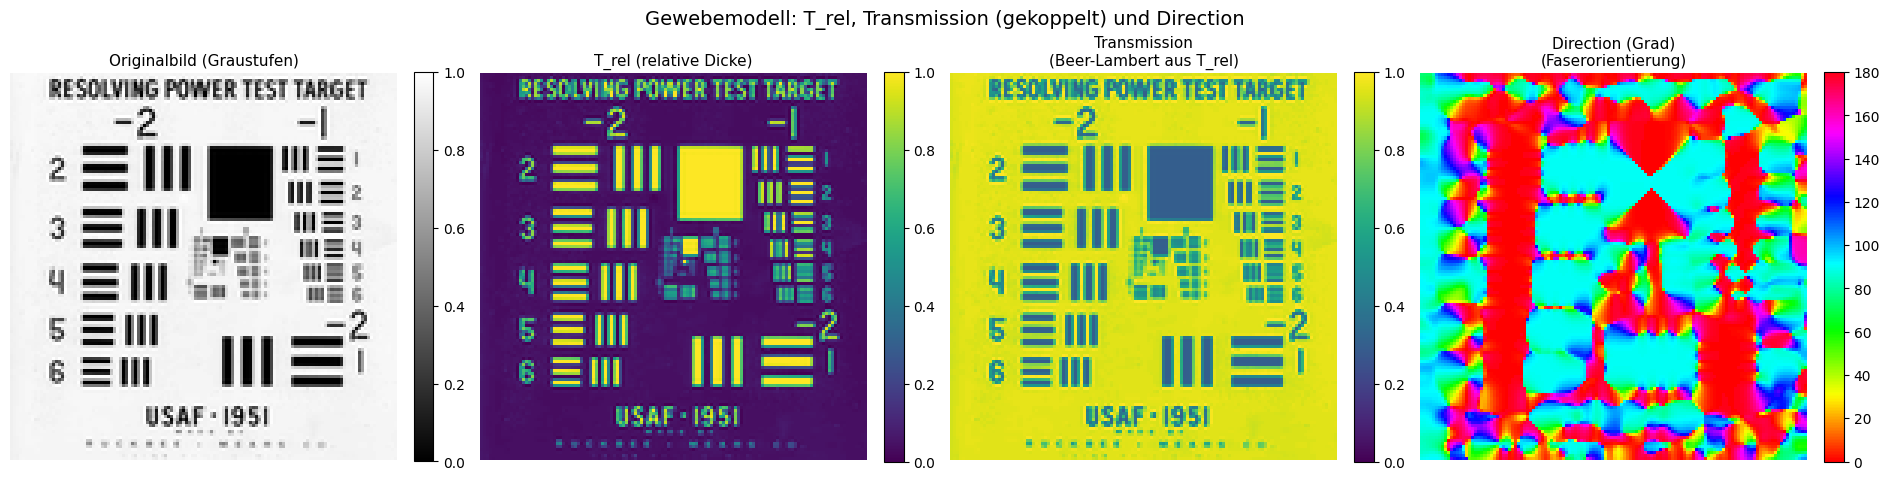

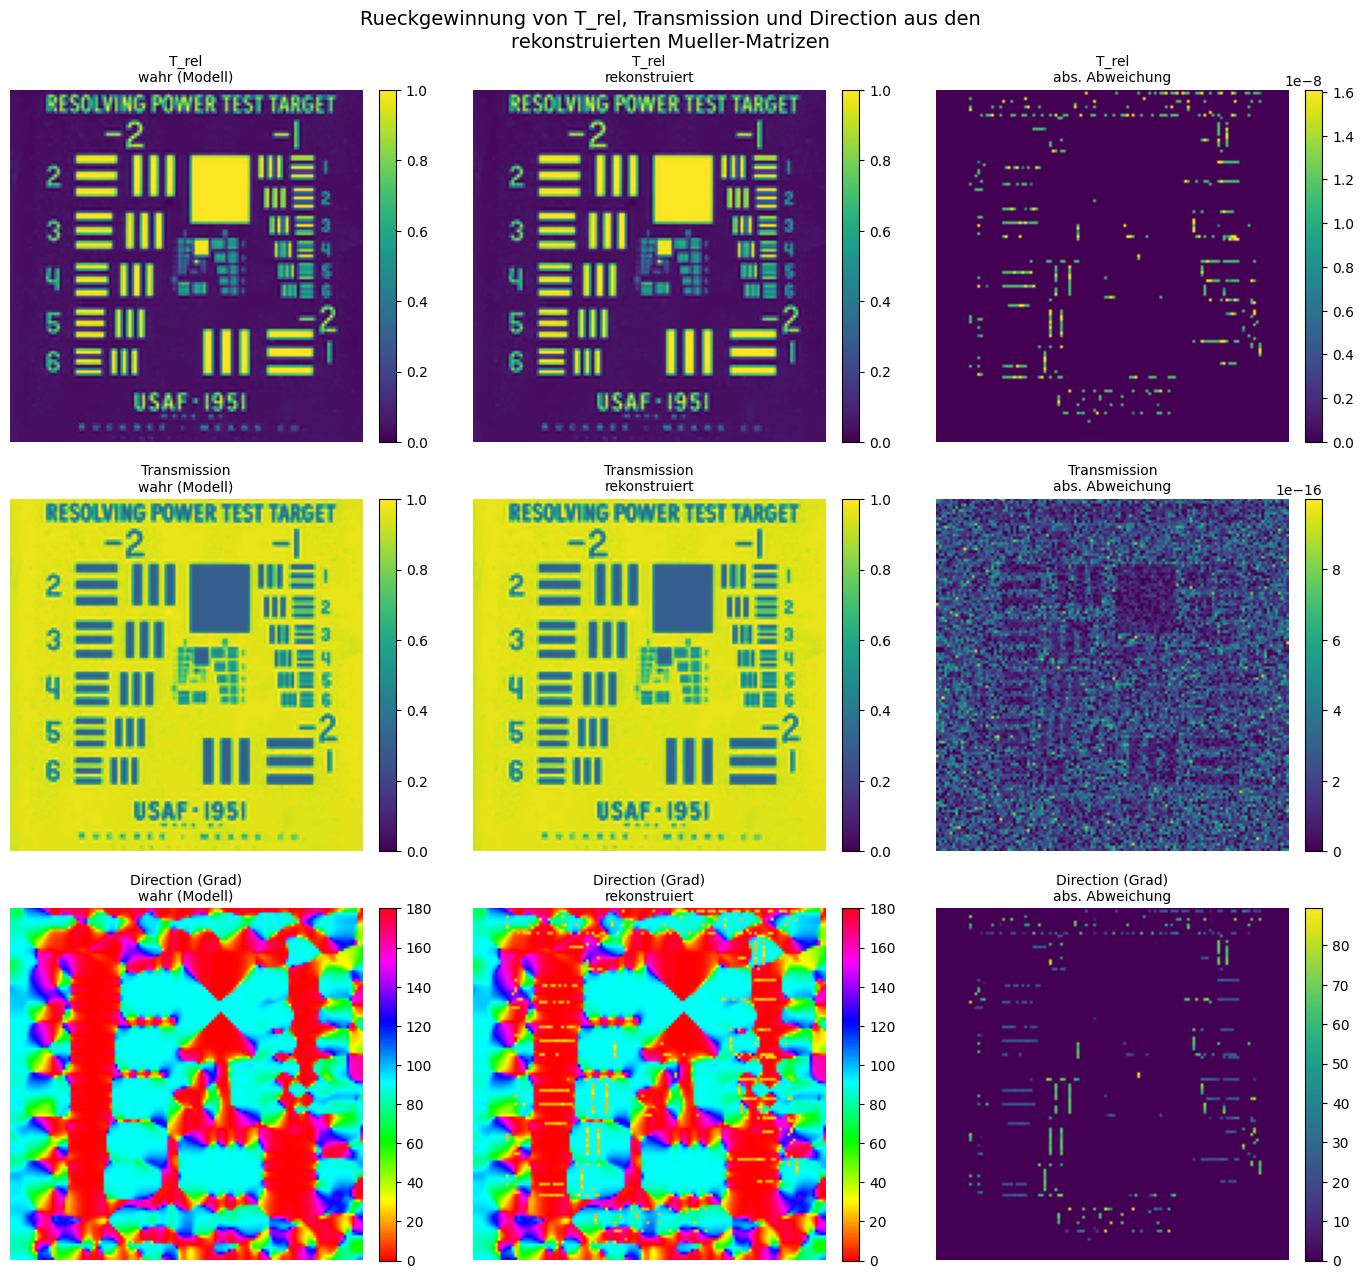

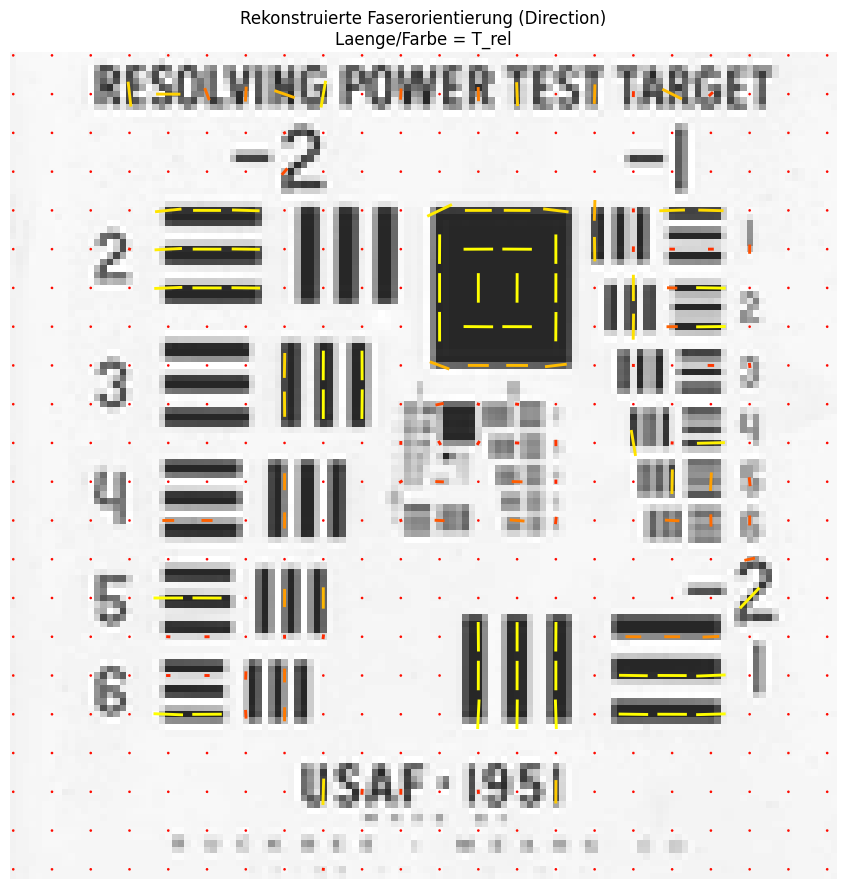

In [ ]:
"""
Mueller-Polarimetrie: Gewebemodell mit Transmission, Direction, T-rel
========================================================================

Aufbau (Dual-Rotating-Retarder-Polarimeter, wie zuvor):
    Laser -> fester Polarisator -> variabler Retarder (theta1)
    -> Gewebeprobe (pixelweise) -> variabler Retarder (theta2)
    -> fester Polarisator -> Detektor

GEWEBEMODELL: 3 gekoppelte Parameter
-------------------------------------
Statt Diattenuation + Depolarisation zu modellieren, nutzen wir hier das
Standard-Parametertrio der bildgebenden Gewebepolarimetrie (analog zu 3D-PLI
an histologischen Schnitten):

    T_rel        relative Gewebedicke, 0..1, direkt aus dem Grauwertbild
    Direction    lokale Faserorientierung (Grad), aus dem Bildgradienten
    Transmission aus T_rel ueber Beer-Lambert:      T = exp(-mu_a * d)
    Retardanz    aus T_rel ueber lineare Doppelbrechung: delta = 360*dn*d/lambda

    mit physikalischer Schichtdicke  d = T_rel * d_max

Transmission und Retardanz sind damit NICHT unabhaengig, sondern beide
Funktionen derselben zugrunde liegenden Groesse (Dicke) -- genau wie in
echtem doppelbrechendem Gewebe: eine dickere Stelle absorbiert mehr UND
dreht die Polarisation staerker.

Die Probe pro Pixel ist ein reiner (nicht-diattenuierender, nicht
depolarisierender) Retarder, skaliert mit der Transmission:

    M_pixel = Transmission * M_Retarder(theta=Direction, delta=Retardanz)

WICHTIG -- Phasen-Wrapping:
    delta(T_rel=1) = delta_max wird bewusst < 180 Grad gehalten. Bei
    delta > 180 Grad waere die Zuordnung delta <-> T_rel nicht mehr eindeutig
    (Wrapping, wie bei einer Phase modulo 360 Grad) -- das vermeiden wir hier
    durch die Wahl von dn und d_max.
"""

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy.ndimage import gaussian_filter, sobel

# ======================================================================
# TEIL 1: Mueller-Grundbausteine
# ======================================================================

def deg2rad(deg):
    return np.deg2rad(deg)


def mueller_rotation(theta_rad):
    c2 = np.cos(2 * theta_rad)
    s2 = np.sin(2 * theta_rad)
    return np.array([
        [1, 0,   0,  0],
        [0, c2,  s2, 0],
        [0, -s2, c2, 0],
        [0, 0,   0,  1],
    ])


def mueller_linear_polarizer(theta_deg, Tmax=1.0, Tmin=0.0):
    theta = deg2rad(theta_deg)
    A = 0.5 * (Tmax + Tmin)
    B = 0.5 * (Tmax - Tmin)
    C = np.sqrt(Tmax * Tmin)
    M0 = np.array([
        [A, B, 0, 0],
        [B, A, 0, 0],
        [0, 0, C, 0],
        [0, 0, 0, C],
    ])
    R = mueller_rotation(theta)
    Rm = mueller_rotation(-theta)
    return Rm @ M0 @ R


def mueller_retarder(theta_deg, delta_deg):
    theta = deg2rad(theta_deg)
    delta = deg2rad(delta_deg)
    c = np.cos(delta)
    s = np.sin(delta)
    M0 = np.array([
        [1, 0, 0,  0],
        [0, 1, 0,  0],
        [0, 0, c,  s],
        [0, 0, -s, c],
    ])
    R = mueller_rotation(theta)
    Rm = mueller_rotation(-theta)
    return Rm @ M0 @ R


# ======================================================================
# TEIL 2: physikalische Konstanten des Gewebemodells
# ======================================================================

BILD_PFAD = "USAFcut.png"
ZIEL_GROESSE = 128

LAMBDA_NM = 532.0        # Wellenlaenge des gruenen Lasers

D_MAX_UM = 30.0          # Schichtdicke bei T_rel = 1 (typische Schnittdicke)
DELTA_N = 0.00739        # Doppelbrechung des Gewebes (Modellparameter)
MU_A_PRO_UM = 0.0401     # Absorptionskoeffizient (Beer-Lambert)

INVERT_DICKE = True      # True: dunkle Bildbereiche = dickeres Gewebe
GLAETTUNG_SIGMA = 2.0    # Glaettung fuer die Richtungsbestimmung (Sobel)

# Bei T_rel = 1 erreichte maximale Retardanz -- zur Kontrolle ausgegeben,
# MUSS deutlich unter 180 Grad bleiben (kein Phasen-Wrapping):
DELTA_MAX_DEG = 360.0 * DELTA_N * (D_MAX_UM * 1000.0) / LAMBDA_NM


def lade_und_skaliere(pfad, groesse):
    img = Image.open(pfad).convert("L")
    img = img.resize((groesse, groesse), Image.LANCZOS)
    return np.asarray(img, dtype=np.float64) / 255.0


def faserrichtung(grau, sigma=GLAETTUNG_SIGMA):
    """
    Lokale Strukturrichtung (Faserorientierung) aus dem Bildgradienten.
    Fasern verlaufen ENTLANG von Kanten, also senkrecht zum Gradienten.
    """
    gx = sobel(grau, axis=1, mode="reflect")
    gy = sobel(grau, axis=0, mode="reflect")

    Jxx = gaussian_filter(gx * gx, sigma)
    Jxy = gaussian_filter(gx * gy, sigma)
    Jyy = gaussian_filter(gy * gy, sigma)

    grad_winkel = 0.5 * np.arctan2(2.0 * Jxy, Jxx - Jyy)
    faser_winkel_rad = grad_winkel + np.pi / 2.0
    return np.rad2deg(faser_winkel_rad) % 180.0


def gewebe_parameterkarten(grau):
    """
    Leitet T_rel, Direction, Transmission und Retardanz aus dem Bild ab.
    Transmission und Retardanz sind ueber die Dicke d = T_rel*d_max gekoppelt.
    """
    T_rel = (1.0 - grau) if INVERT_DICKE else grau.copy()

    d_um = T_rel * D_MAX_UM
    d_nm = d_um * 1000.0

    transmission = np.exp(-MU_A_PRO_UM * d_um)
    retardanz_deg = 360.0 * DELTA_N * d_nm / LAMBDA_NM

    direction_deg = faserrichtung(grau)

    return {
        "T_rel": T_rel,
        "direction_deg": direction_deg,
        "transmission": transmission,
        "retardanz_deg": retardanz_deg,
    }


# ======================================================================
# TEIL 3: Parameterkarten -> pixelweise Mueller-Matrizen (vektorisiert)
# ======================================================================

def baue_mueller_stapel(karten):
    """
    M_pixel = Transmission * M_Retarder(theta=Direction, delta=Retardanz)
    Reiner Retarder, skaliert -- keine Diattenuation, keine Depolarisation.
    """
    tau = karten["transmission"].flatten()
    delta = deg2rad(karten["retardanz_deg"].flatten())
    theta = deg2rad(karten["direction_deg"].flatten())
    N = tau.size

    cd, sd = np.cos(delta), np.sin(delta)
    M_R0 = np.zeros((N, 4, 4))
    M_R0[:, 0, 0] = 1.0
    M_R0[:, 1, 1] = 1.0
    M_R0[:, 2, 2] = cd
    M_R0[:, 2, 3] = sd
    M_R0[:, 3, 2] = -sd
    M_R0[:, 3, 3] = cd

    c2, s2 = np.cos(2 * theta), np.sin(2 * theta)
    Rp = np.zeros((N, 4, 4))
    Rp[:, 0, 0] = 1.0
    Rp[:, 1, 1] = c2
    Rp[:, 1, 2] = s2
    Rp[:, 2, 1] = -s2
    Rp[:, 2, 2] = c2
    Rp[:, 3, 3] = 1.0

    Rm = np.zeros((N, 4, 4))
    Rm[:, 0, 0] = 1.0
    Rm[:, 1, 1] = c2
    Rm[:, 1, 2] = -s2
    Rm[:, 2, 1] = s2
    Rm[:, 2, 2] = c2
    Rm[:, 3, 3] = 1.0

    M_R = Rm @ M_R0 @ Rp                       # reiner Retarder pro Pixel
    return tau[:, None, None] * M_R            # mit Transmission skaliert


# ======================================================================
# TEIL 4: Messmatrix des Dual-Rotating-Retarder-Polarimeters
# ======================================================================

RETARDANZ_PSG_PSA = 132.0
POL_EIN = 0.0
POL_AUS = 0.0
I0 = 1.0


def baue_messmatrix(theta1_liste, theta2_liste, retardanz=RETARDANZ_PSG_PSA):
    zeilen = []
    M_pol_ein = mueller_linear_polarizer(POL_EIN)
    M_pol_aus = mueller_linear_polarizer(POL_AUS)
    S_quelle = np.array([I0, 0, 0, 0])

    for th1 in theta1_liste:
        s_in = mueller_retarder(th1, retardanz) @ M_pol_ein @ S_quelle
        for th2 in theta2_liste:
            a = (M_pol_aus @ mueller_retarder(th2, retardanz))[0, :]
            zeilen.append(np.outer(a, s_in).flatten())
    return np.array(zeilen)


# ======================================================================
# TEIL 5: Rueckgewinnung von T_rel, Direction, Transmission
# ======================================================================

def zerlegung_reiner_retarder(M):
    """
    Zerlegt einen Stapel M = tau * M_Retarder(theta, delta) (N,4,4)
    zurueck in tau, delta, theta. Da keine Diattenuation/Depolarisation
    vorhanden ist, ist diese Zerlegung exakt und braucht keine Iteration:

        tau   = M00
        m     = M[1:,1:] / tau        (reine Rotationsmatrix im 3x3-Sinn)
        delta = arccos((trace(m) - 1) / 2)
        theta = 0.5 * atan2(a2, a1),  a_i aus den Retardanzvektor-Formeln
    """
    tau = M[:, 0, 0]
    tau_safe = np.where(np.abs(tau) < 1e-12, 1e-12, tau)
    m = M[:, 1:, 1:] / tau_safe[:, None, None]

    spur = np.trace(m, axis1=1, axis2=2)
    cos_delta = np.clip((spur - 1.0) / 2.0, -1.0, 1.0)
    delta_rad = np.arccos(cos_delta)

    sin_delta = np.sin(delta_rad)
    sin_safe = np.where(np.abs(sin_delta) < 1e-9, 1e-9, sin_delta)
    a1 = (m[:, 1, 2] - m[:, 2, 1]) / (2.0 * sin_safe)
    a2 = (m[:, 2, 0] - m[:, 0, 2]) / (2.0 * sin_safe)
    theta_rad = 0.5 * np.arctan2(a2, a1)

    return {
        "transmission": tau,
        "retardanz_deg": np.rad2deg(delta_rad),
        "direction_deg": np.rad2deg(theta_rad) % 180.0,
    }


def retardanz_zu_T_rel(retardanz_deg):
    """Kehrt delta = 360*dn*d/lambda, d = T_rel*d_max nach T_rel um."""
    return retardanz_deg / DELTA_MAX_DEG


# ======================================================================
# TEIL 6: Hauptprogramm
# ======================================================================

if __name__ == "__main__":

    RAUSCHEN_SIGMA = 0.0

    print(f"Maximale Retardanz bei T_rel=1: {DELTA_MAX_DEG:.1f} Grad "
          f"({'OK, < 180 Grad, kein Wrapping' if DELTA_MAX_DEG < 180 else 'ACHTUNG: Wrapping moeglich!'})")

    grau = lade_und_skaliere(BILD_PFAD, ZIEL_GROESSE)
    H, W_px = grau.shape
    N_pixel = H * W_px
    karten = gewebe_parameterkarten(grau)

    print(f"\nBild: {H}x{W_px} = {N_pixel} Gewebe-Pixel")
    print(f"  T_rel        : {karten['T_rel'].min():.2f} .. {karten['T_rel'].max():.2f}")
    print(f"  Transmission : {karten['transmission'].min():.3f} .. {karten['transmission'].max():.3f}")
    print(f"  Retardanz    : {karten['retardanz_deg'].min():.1f} .. {karten['retardanz_deg'].max():.1f} Grad")
    print(f"  Direction    : {karten['direction_deg'].min():.1f} .. {karten['direction_deg'].max():.1f} Grad")

    # ---------- wahre Mueller-Matrizen ----------
    M_true = baue_mueller_stapel(karten)
    M_true_flat = M_true.reshape(N_pixel, 16).T

    # ---------- Messung simulieren ----------
    theta1_liste = np.linspace(0, 180, 16, endpoint=False)
    theta2_liste = np.linspace(0, 180, 16, endpoint=False)
    Wmat = baue_messmatrix(theta1_liste, theta2_liste)
    print(f"\nMessmatrix: {Wmat.shape[0]} Messungen, Konditionszahl {np.linalg.cond(Wmat):.1f}")

    I_sim = Wmat @ M_true_flat
    if RAUSCHEN_SIGMA > 0:
        rng = np.random.default_rng(0)
        I_sim = I_sim + rng.normal(0, RAUSCHEN_SIGMA * I_sim.max(), I_sim.shape)

    # ---------- Rekonstruktion der Mueller-Matrix ----------
    M_recon_flat = np.linalg.pinv(Wmat) @ I_sim
    M_recon = M_recon_flat.T.reshape(N_pixel, 4, 4)

    fehler = np.abs(M_recon_flat - M_true_flat)
    print(f"Max. Rekonstruktionsfehler (Matrixelemente): {fehler.max():.2e}")

    # ---------- Rueckgewinnung der physikalischen Parameter ----------
    rek = zerlegung_reiner_retarder(M_recon)
    T_rel_rek = retardanz_zu_T_rel(rek["retardanz_deg"])

    def als_bild(x):
        return x.reshape(H, W_px)

    transmission_rek_img = als_bild(rek["transmission"])
    retardanz_rek_img = als_bild(rek["retardanz_deg"])
    direction_rek_img = als_bild(rek["direction_deg"])
    T_rel_rek_img = als_bild(T_rel_rek)

    def winkel_fehler(a, b):
        d = np.abs(a - b) % 180.0
        return np.minimum(d, 180.0 - d)

    maske = karten["retardanz_deg"] > 10.0  # Achse nur bei genuegend Retardanz definiert

    print("\nRueckgewinnung der Gewebeparameter:")
    print(f"  Transmission : mittl. Fehler {np.abs(transmission_rek_img - karten['transmission']).mean():.2e}")
    print(f"  T_rel        : mittl. Fehler {np.abs(T_rel_rek_img - karten['T_rel']).mean():.2e}")
    print(f"  Direction    : mittl. Fehler {winkel_fehler(direction_rek_img, karten['direction_deg'])[maske].mean():.4f} Grad"
          f"  (nur Pixel mit Retardanz > 10 Grad)")

    # ==================================================================
    # Visualisierung
    # ==================================================================

    # --- Abb. 1: die drei Gewebe-Parameterkarten (Ground Truth) ---
    fig1, ax1 = plt.subplots(1, 4, figsize=(19, 5))
    eintraege = [
        (grau, "Originalbild (Graustufen)", "gray", None),
        (["T_rel"], "T_rel (relative Dicke)", "viridis", (0, 1)),
        (karten["transmission"], "Transmission\n(Beer-Lambert aus T_rel)", "viridis", (0, 1)),
        (karten["direction_deg"], "Direction (Grad)\n(Faserorientierung)", "hsv", (0, 180)),
    ]
    for ax, (bild, titel, cmap, lim) in zip(ax1, eintraege):
        kw = {"vmin": lim[0], "vmax": lim[1]} if lim else {}
        im = ax.imshow(bild, cmap=cmap, **kw)
        ax.set_title(titel, fontsize=11)
        ax.axis("off")
        fig1.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig1.suptitle("Gewebemodell: T_rel, Transmission (gekoppelt) und Direction", fontsize=14)
    fig1.tight_layout()
    #fig1.savefig("outputs/tdr_parameterkarten.png", dpi=150)

    # --- Abb. 2: wahr vs. rekonstruiert ---
    fig2, ax2 = plt.subplots(3, 3, figsize=(14, 13))
    vergleiche = [
        (karten["T_rel"], T_rel_rek_img, "T_rel", "viridis", (0, 1)),
        (karten["transmission"], transmission_rek_img, "Transmission", "viridis", (0, 1)),
        (karten["direction_deg"], direction_rek_img, "Direction (Grad)", "hsv", (0, 180)),
    ]
    for zeile, (wahr, rek_bild, titel, cmap, lim) in enumerate(vergleiche):
        kw = {"vmin": lim[0], "vmax": lim[1]} if lim else {}
        im0 = ax2[zeile, 0].imshow(wahr, cmap=cmap, **kw)
        ax2[zeile, 0].set_title(f"{titel}\nwahr (Modell)", fontsize=10)
        fig2.colorbar(im0, ax=ax2[zeile, 0], fraction=0.046, pad=0.04)

        im1 = ax2[zeile, 1].imshow(rek_bild, cmap=cmap, **kw)
        ax2[zeile, 1].set_title(f"{titel}\nrekonstruiert", fontsize=10)
        fig2.colorbar(im1, ax=ax2[zeile, 1], fraction=0.046, pad=0.04)

        diff = winkel_fehler(rek_bild, wahr) if "Direction" in titel else np.abs(rek_bild - wahr)
        im2 = ax2[zeile, 2].imshow(diff, cmap="viridis")
        ax2[zeile, 2].set_title(f"{titel}\nabs. Abweichung", fontsize=10)
        fig2.colorbar(im2, ax=ax2[zeile, 2], fraction=0.046, pad=0.04)

        for k in range(3):
            ax2[zeile, k].axis("off")
    fig2.suptitle("Rueckgewinnung von T_rel, Transmission und Direction aus den\n"
                  "rekonstruierten Mueller-Matrizen", fontsize=14)
    fig2.tight_layout()
    #fig2.savefig("outputs/tdr_rekonstruktion_vergleich.png", dpi=150)

    # --- Abb. 3: Faserorientierung als Vektorfeld ---
    schritt = 6
    yy, xx = np.mgrid[0:H:schritt, 0:W_px:schritt]
    winkel_sub = np.deg2rad(direction_rek_img[::schritt, ::schritt])
    laenge = retardanz_rek_img[::schritt, ::schritt] / DELTA_MAX_DEG
    u = laenge * np.cos(winkel_sub)
    v = -laenge * np.sin(winkel_sub)

    fig3, ax3 = plt.subplots(figsize=(9, 9))
    ax3.imshow(grau, cmap="gray", alpha=0.85)
    ax3.quiver(xx, yy, u, v, laenge, cmap="autumn",
               pivot="mid", headwidth=0, headlength=0, headaxislength=0,
               scale=28, width=0.0035)
    ax3.set_title("Rekonstruierte Faserorientierung (Direction)\n"
                  "Laenge/Farbe = T_rel", fontsize=12)
    ax3.axis("off")
    fig3.tight_layout()
    #fig3.savefig("outputs/tdr_faserorientierung.png", dpi=150)

    print("\nPlots gespeichert:")
    print("  tdr_parameterkarten.png")
    print("  tdr_rekonstruktion_vergleich.png")
    print("  tdr_faserorientierung.png")